# Notebook 3 — Time-Series Forecasting with Holt-Winters

**MediShift · Forecasting Engine, Model 3 of 3**

Ridge Regression and Gradient-Boosted Stumps (Notebooks 1–2) both treat every
shift record as an independent set of features. Patient inflow is also, quite
literally, a **time series**: it has a level that drifts, a trend, and a
strong weekly rhythm (Monday looks different from Sunday, and Morning looks
very different from Night). This notebook implements MediShift's third
forecasting model, described in report **Section 2.4**: **Holt-Winters triple
exponential smoothing**, chosen deliberately over ARIMA because it updates
with simple, non-iterative formulas that can refit instantly on a phone every
time a new shift is logged.

**What this notebook covers**

1. Load the shift dataset as a single chronological time series
2. Derive the three Holt-Winters update equations — level, trend, season — from the underlying intuition
3. Explain why Holt-Winters was chosen over ARIMA for an on-device model
4. Implement the recursive smoother from scratch and run it end-to-end over 3 years of shifts
5. Evaluate one-step-ahead forecasts on the same held-out period as Notebooks 1–2
6. Decompose a forecast into its level / trend / season components and visualise each
7. Save this model's held-out predictions for the ensemble notebook (Notebook 4)

## 1. Setup & Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#52514E"
plt.rcParams["axes.labelcolor"] = "#0B0B0B"
plt.rcParams["text.color"] = "#0B0B0B"
plt.rcParams["xtick.color"] = "#52514E"
plt.rcParams["ytick.color"] = "#52514E"

C = {
    "blue": "#2A78D6", "orange": "#EB6834", "aqua": "#1BAF7A",
    "yellow": "#EDA100", "violet": "#4A3AA7", "ink": "#0B0B0B",
    "muted": "#898781", "hair": "#E1E0D9", "surface": "#FCFCFB",
}
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

with open("shift_dataset_3years.json") as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "id"]).reset_index(drop=True)

y = df["patient_inflow"].values.astype(float)
N = len(y)
SPLIT = int(N * 0.8)   # identical split to Notebooks 1-2
print(f"Records: {N:,}  |  Training: {SPLIT:,}  |  Held-out: {N - SPLIT:,}")

Records: 3,291  |  Training: 2,632  |  Held-out: 659


## 2. Why Not ARIMA?

ARIMA is the best-known family for this kind of problem: it predicts a value
from past values (the *autoregressive* part) and past forecast errors (the
*moving-average* part), after removing trend by differencing. It is powerful,
but fitting it well needs an iterative maximum-likelihood search — too heavy
for a model that is expected to refit instantly every time a receptionist logs
one more shift on a phone with no server.

**Holt-Winters triple exponential smoothing** models the same
level / trend / seasonal structure, but with simple, closed-form,
non-iterative update rules applied once per new observation.

## 3. Deriving the Three Update Equations

Patient inflow at time $t$ is decomposed into three time-varying pieces: a
**level** $L_t$ (where the series currently sits), a **trend** $T_t$ (how fast
the level is drifting), and a **seasonal** component $S_t$ (the repeating
weekly deviation for this specific shift slot). Each is updated by blending a
fresh estimate from the newest observation with the previous estimate — the
defining idea of exponential smoothing.

**Level.** The new level should reflect this shift's *de-seasonalised* value,
$y_t - S_{t-m}$ (last observation, with its usual seasonal effect removed),
blended with what the level *would have been* by simply continuing the
previous trend, $L_{t-1}+T_{t-1}$:

$$
L_t = \alpha\,(y_t - S_{t-m}) + (1-\alpha)\,(L_{t-1}+T_{t-1}).
\tag{2.5}
$$

**Trend.** The new trend blends the level's most recent change,
$L_t - L_{t-1}$, with the previous trend estimate:

$$
T_t = \beta\,(L_t - L_{t-1}) + (1-\beta)\,T_{t-1}.
\tag{2.6}
$$

**Season.** The new seasonal factor for this position in the cycle blends how
far the newest observation sits above or below the freshly updated level,
$y_t - L_t$, with the seasonal estimate this slot carried last cycle:

$$
S_t = \gamma\,(y_t - L_t) + (1-\gamma)\,S_{t-m}.
\tag{2.7}
$$

Here $\alpha=0.35$, $\beta=0.12$, $\gamma=0.20$ (report Section 2.4) control
how quickly each component reacts to new information, and $m=21$ is the length
of one full seasonal cycle: 7 days $\times$ 3 shifts. Because the update
already blends in new data at a fixed rate, Holt-Winters needs no separate
recency-weight array the way Notebooks 1 and 2 do — recency bias is built into
$\alpha$, $\beta$, $\gamma$ directly.

**Forecasting $h$ shifts ahead** reads straight off the fitted state, no
re-estimation needed:

$$
\hat y_{t+h} = L_t + h\,T_t + S_{t+h-m}.
$$

For $h=1$ (the one-step-ahead forecasts this notebook evaluates), this is
simply $\hat y_{t+1} = L_t + T_t + S_{t+1-m}$.

## 4. Implementation

The recursion needs to be *initialised* before it can update: a starting level
$L_0$, a starting trend $T_0$, and $m=21$ starting seasonal factors, one per
shift slot in the weekly cycle. A simple, standard initialisation is used —
the first observation as the starting level, the average change over the
first full cycle as the starting trend, and each slot's first-cycle deviation
from that starting level as its starting seasonal factor.

At every subsequent time step $t$, the *current* state is used to produce the
one-step-ahead forecast $\hat y_t$ *before* that state is updated with the
newly-arrived actual $y_t$ — exactly what an on-device model does in
production: predict, then learn.

In [2]:
def holt_winters_fit_predict(y, alpha=0.35, beta=0.12, gamma=0.20, m=21):
    '''Runs Holt-Winters triple exponential smoothing sequentially over the
    whole series, producing a one-step-ahead forecast for every time step
    (using only state built from observations strictly before it), then
    updating the level/trend/season state with that step's actual value.

    Returns (forecasts, levels, trends, seasonals_history).
    '''
    n = len(y)
    level = y[0]
    trend = (y[m] - y[0]) / m if n > m else 0.0
    season = np.zeros(m)
    for i in range(min(m, n)):
        season[i] = y[i] - level

    forecasts = np.zeros(n)
    levels = np.zeros(n)
    trends = np.zeros(n)
    seasonals = np.zeros(n)

    for t in range(n):
        s_idx = t % m
        forecasts[t] = level + trend + season[s_idx]   # one-step-ahead, h=1

        new_level = alpha * (y[t] - season[s_idx]) + (1 - alpha) * (level + trend)
        new_trend = beta * (new_level - level) + (1 - beta) * trend
        season[s_idx] = gamma * (y[t] - new_level) + (1 - gamma) * season[s_idx]

        level, trend = new_level, new_trend
        levels[t], trends[t], seasonals[t] = level, trend, season[s_idx]

    return forecasts, levels, trends, seasonals

In [3]:
ALPHA, BETA, GAMMA, M = 0.35, 0.12, 0.20, 21

forecasts, levels, trends, seasonals = holt_winters_fit_predict(y, ALPHA, BETA, GAMMA, M)

y_train, y_test = y[:SPLIT], y[SPLIT:]
pred_train, pred_test = forecasts[:SPLIT], forecasts[SPLIT:]
dates_test = df["date"].values[SPLIT:]

print("First 10 one-step-ahead forecasts vs. actuals (early in the series, "
      "state is still settling in):")
pd.DataFrame({"actual": y[:10], "forecast": forecasts[:10]})

First 10 one-step-ahead forecasts vs. actuals (early in the series, state is still settling in):


,actual,forecast
0,"1,141.00","1,136.76"
1,560.00,553.19
2,289.00,280.80
3,938.00,929.24
4,542.00,533.24
5,276.00,267.61
6,949.00,941.21
7,478.00,470.92
8,238.00,231.68
9,"1,258.00","1,252.44"


## 5. Evaluate on Held-Out Shifts

The same held-out window used in Notebooks 1 and 2 (the final 20% of shifts
chronologically) is used here too — even though Holt-Winters is fit
sequentially over the *entire* series rather than split into a separate
"training" pass, every forecast in the held-out window still only used state
built from strictly earlier observations, so the comparison is fair.

In [4]:
def evaluate(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

metrics_train = evaluate(y_train, pred_train)
metrics_test  = evaluate(y_test,  pred_test)
metrics_df = pd.DataFrame([metrics_train, metrics_test], index=["Train (in-sample)", "Held-out (test)"])
metrics_df

,MAE,RMSE,R2
Train (in-sample),52.28,68.83,0.95
Held-out (test),53.49,68.80,0.95


Holt-Winters comes out the strongest of the three individual models on this
dataset — which makes sense given *how* patient inflow varies here: the
overwhelming majority of the swing in the data is the repeating
Morning/Evening/Night pattern, exactly the 21-slot seasonal structure this
model is built to track natively, with the seasonal component re-estimated
fresh from every cycle rather than inferred indirectly through a rolling
average or a one-hot indicator.

## 6. Decomposing a Forecast

Holt-Winters' biggest advantage over the previous two models is
interpretability of a different kind: at any moment, the fitted state can be
read directly as "where the series sits" (level), "which way it's moving"
(trend), and "how this specific shift slot deviates from that" (season).

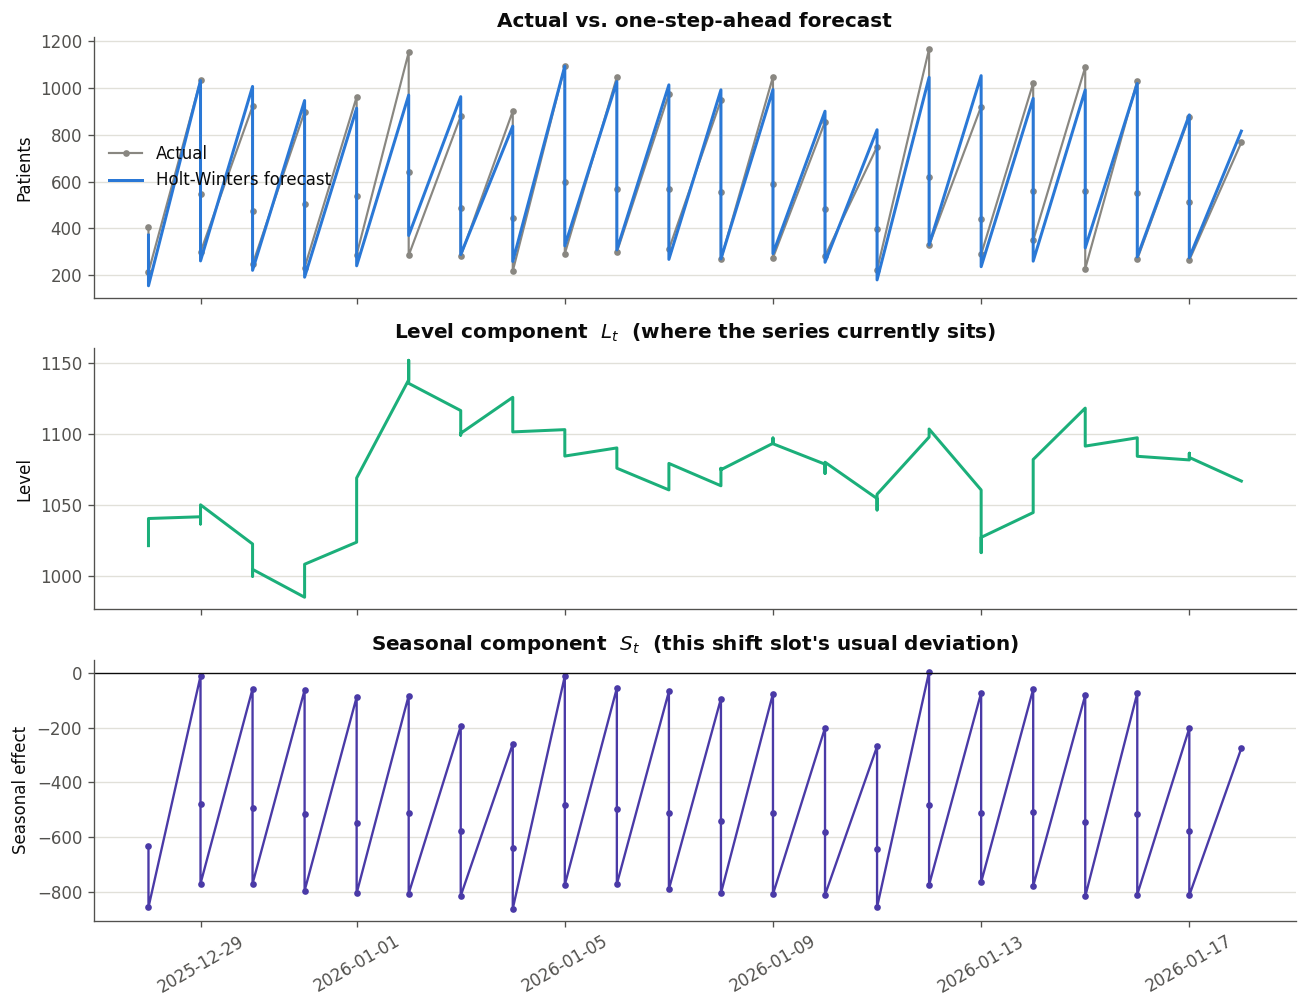

In [5]:
window = slice(SPLIT, SPLIT + 63)  # 3 weeks into the held-out period

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)

axes[0].plot(dates_test[:63], y[window], color=C["muted"], lw=1.3, marker="o", ms=3, label="Actual")
axes[0].plot(dates_test[:63], forecasts[window], color=C["blue"], lw=1.8, label="Holt-Winters forecast")
axes[0].set_title("Actual vs. one-step-ahead forecast", fontweight="bold", color=C["ink"])
axes[0].legend(frameon=False)
axes[0].set_ylabel("Patients")

axes[1].plot(dates_test[:63], levels[window], color=C["aqua"], lw=1.8)
axes[1].set_title("Level component  $L_t$  (where the series currently sits)", fontweight="bold", color=C["ink"])
axes[1].set_ylabel("Level")

axes[2].plot(dates_test[:63], seasonals[window], color=C["violet"], lw=1.4, marker="o", ms=3)
axes[2].axhline(0, color=C["ink"], lw=0.8)
axes[2].set_title("Seasonal component  $S_t$  (this shift slot's usual deviation)", fontweight="bold", color=C["ink"])
axes[2].set_ylabel("Seasonal effect")

for ax in axes:
    ax.grid(axis="y", color=C["hair"])
    ax.set_axisbelow(True)
for label in axes[2].get_xticklabels():
    label.set_rotation(30)

plt.tight_layout()
plt.show()

**Reading the decomposition.** The level (middle panel) moves in a far
narrower band than the raw data (roughly 1,000–1,150, against a raw range of
about 130–1,460) — most of the sharp Morning/Evening/Night sawtooth has been
absorbed elsewhere. A faint trace of it still leaks through as a small zigzag,
since the level update in Equation (2.5) de-seasonalises using *last cycle's*
seasonal estimate, $S_{t-m}$, not a perfectly settled one — an honest,
expected artefact of an online, non-iterative smoother rather than a bug. The
seasonal component (bottom panel) is where the sawtooth actually lives: it
snaps between a value near zero (Morning shifts run close to the level), a
sharp drop to roughly $-500$ (Evening), and a much deeper drop to roughly
$-800$ (Night runs far below the level), cycling every 3 slots within the
21-slot week. This is exactly the decomposition Equation (2.7) is designed to
produce, and it is the reason Holt-Winters needs no explicit shift-type
feature the way Notebooks 1 and 2 do — the seasonal array *is* the shift-type
effect, learned automatically.

## 7. From One Shift to a Full Roster Week

Section 2.5 of the report explains why a single forecast is not enough:
the roster in Chapter 3 needs one forecast for *every* day of its
Monday-through-Sunday template, not one day's number copied across all seven.
Holt-Winters already carries this structure natively — its 21-slot seasonal
array spans a full week, so evaluating the forecast formula out to
$h=1,\dots,21$ (instead of stopping at the very next occurrence of each shift
type) produces a genuine forecast for every shift of the coming roster week in
one pass. One indexing detail matters here: the seasonal array is indexed by
*absolute* time modulo 21, not by "steps since the last record," so the
21-step horizon has to be offset by the last record's own slot,
$t_0 \bmod 21$, or every forecast would silently land on the wrong shift type.

In [6]:
def forecast_next_week(level, trend, season, last_slot, m=21):
    '''Evaluate y_hat_{t0+h} = L_{t0} + h*T_{t0} + S_{(t0+h) mod m} for h = 1..m,
    where t0 is the index of the last observed record and last_slot = t0 mod m
    -- producing one forecast per shift of the coming 7-day roster week.'''
    horizon = np.arange(1, m + 1)
    seasonal_idx = (last_slot + horizon) % m
    return level + horizon * trend + season[seasonal_idx]

last_level, last_trend = levels[-1], trends[-1]
# reconstruct the full 21-slot seasonal array as it stood at the very end of the
# series: the last M=21 consecutive records touch every slot (t % M) exactly
# once, so this recovers each slot's freshest fitted value.
final_season_array = np.zeros(M)
for t in range(N - M, N):
    final_season_array[t % M] = seasonals[t]

# The seasonal array is indexed by absolute time mod M, not by "steps since
# the last record" -- so the forecast horizon must be offset by the last
# record's own slot, (N-1) % M, or every forecast lands on the wrong shift.
last_slot = (N - 1) % M
next_week = forecast_next_week(last_level, last_trend, final_season_array, last_slot, M)

# Slot index t % M is anchored to the dataset's own calendar (record 0 is a
# Morning shift on the dataset's start date), NOT to a fixed Monday start --
# so the coming week's (date, shift) sequence is built by continuing forward
# from the dataset's actual last record, in its native Morning -> Evening ->
# Night -> next-day-Morning cycle, rather than assumed.
SHIFT_CYCLE = ["Morning", "Evening", "Night"]
last_date = df["date"].iloc[-1]
last_shift_idx = SHIFT_CYCLE.index(df["shift_type"].iloc[-1])

cal_dates, cal_shifts = [], []
cur_date, cur_idx = last_date, last_shift_idx
for _ in range(M):
    cur_idx += 1
    if cur_idx == 3:
        cur_idx = 0
        cur_date = cur_date + pd.Timedelta(days=1)
    cal_dates.append(cur_date)
    cal_shifts.append(SHIFT_CYCLE[cur_idx])

roster_week = pd.DataFrame({
    "date": cal_dates,
    "day": [d.strftime("%a") for d in cal_dates],
    "shift": cal_shifts,
    "forecast_patients": np.round(next_week).astype(int),
})
roster_week

,date,day,shift,forecast_patients
0,2026-08-05,Wed,Morning,1088
1,2026-08-05,Wed,Evening,596
2,2026-08-05,Wed,Night,306
3,2026-08-06,Thu,Morning,1089
4,2026-08-06,Thu,Evening,619
5,2026-08-06,Thu,Night,317
6,2026-08-07,Fri,Morning,1192
7,2026-08-07,Fri,Evening,640
8,2026-08-07,Fri,Night,343
9,2026-08-08,Sat,Morning,1084


This table is Holt-Winters' contribution to the blended per-day forecast
$\{\hat y_d\}$ that Chapter 3's staffing model actually consumes (Equation
2.11) — one row per shift of the coming week, produced from a single fitted
state, with no re-fitting needed for each day individually. Notebook 4 blends
this alongside Ridge Regression's and the boosted-stumps model's own versions
of the same forecast.

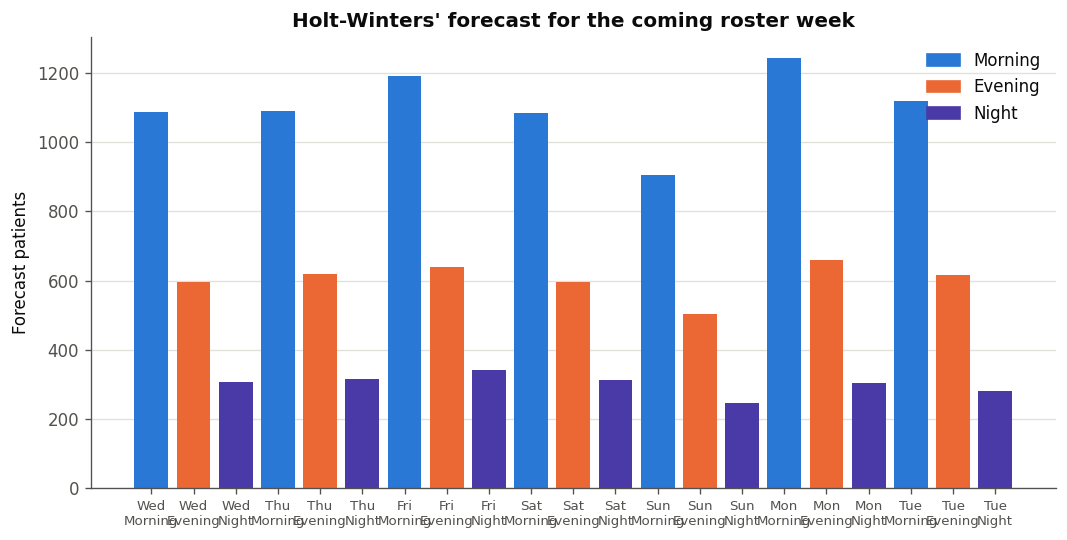

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.6))
colors_by_shift = {"Morning": C["blue"], "Evening": C["orange"], "Night": C["violet"]}
x = np.arange(len(roster_week))
bar_colors = [colors_by_shift[s] for s in roster_week["shift"]]
ax.bar(x, roster_week["forecast_patients"], color=bar_colors)
ax.set_xticks(x)
ax.set_xticklabels([f"{d}\n{s}" for d, s in zip(roster_week["day"], roster_week["shift"])], fontsize=8)
ax.set_ylabel("Forecast patients")
ax.set_title("Holt-Winters' forecast for the coming roster week", fontweight="bold", color=C["ink"])
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=s) for s, c in colors_by_shift.items()]
ax.legend(handles=handles, frameon=False)

plt.tight_layout()
plt.show()

## 8. Save Predictions for the Ensemble Notebook

In [8]:
import os
os.makedirs("artifacts", exist_ok=True)

out = pd.DataFrame({
    "date": pd.to_datetime(dates_test),
    "shift_type": df["shift_type"].values[SPLIT:],
    "y_true": y_test,
    "y_pred_holt": pred_test,
})
out.to_csv("artifacts/holt_predictions.csv", index=False)

print(f"Saved {len(out):,} held-out predictions to artifacts/holt_predictions.csv")
print(f"Held-out MAE for this model (used as the ensemble weight input in Notebook 4): {metrics_test['MAE']:.3f}")
out.head()

Saved 659 held-out predictions to artifacts/holt_predictions.csv
Held-out MAE for this model (used as the ensemble weight input in Notebook 4): 53.489


,date,shift_type,y_true,y_pred_holt
0,2025-12-28,Evening,406.00,371.30
1,2025-12-28,Night,214.00,155.27
2,2025-12-29,Morning,"1,031.00","1,030.63"
3,2025-12-29,Evening,548.00,565.82
4,2025-12-29,Night,299.00,261.28


## Summary

| | |
|---|---|
| **Model** | Holt-Winters triple exponential smoothing, from scratch |
| **Parameters** | $\alpha=0.35$, $\beta=0.12$, $\gamma=0.20$ |
| **Seasonal cycle** | $m=21$ (7 days $\times$ 3 shifts) |
| **Held-out MAE** | see Section 5 above |
| **Held-out R²** | see Section 5 above |

Holt-Winters is the only one of MediShift's three models that reasons about
time directly rather than treating every shift as an independent row of
features — and on this dataset, where the dominant source of variation is a
strongly repeating weekly pattern, that turns out to matter a great deal. Its
limitation is the flip side of that strength: it has no way to react to a
feature it has never been told about, like an upcoming public holiday, until
that effect has already shown up in the data enough times to bend the
seasonal array — which is exactly the gap the heuristic term in Notebook 4's
ensemble blend (Equation 2.9) is designed to fill.